In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

In [2]:
# Load the dataset
wine_data = pd.read_csv(r'D:\ML PROJECTS\finaltics ml projects\wine quality analysis\wine_data.csv')

# Display basic information
print("Dataset shape:", wine_data.shape)
print("\nFirst 5 rows:")
print(wine_data.head())

# Check for missing values
print("\nMissing values:")
print(wine_data.isnull().sum())

# Basic statistics
print("\nDescriptive statistics:")
print(wine_data.describe())

# Data types
print("\nData types:")
print(wine_data.dtypes)

Dataset shape: (1599, 12)

First 5 rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1


Quality distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Most frequent quality: 5
Highest quality: 8
Lowest quality: 3


C:\Users\yuvan\AppData\Local\Temp\ipykernel_18776\2781894879.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=wine_data, palette='viridis')


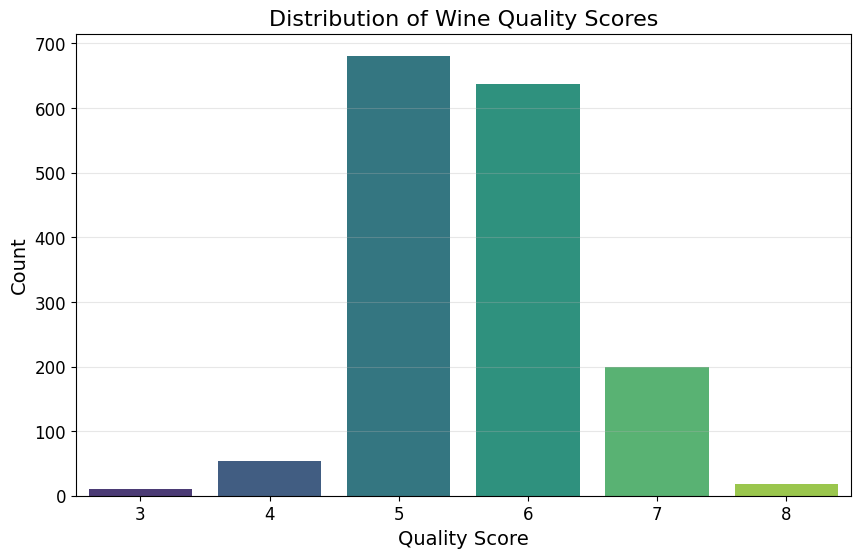

In [3]:
# Question 1: Most frequent, highest and lowest quality
quality_counts = wine_data['quality'].value_counts().sort_index()
print("\nQuality distribution:")
print(quality_counts)

most_frequent = quality_counts.idxmax()
highest_quality = wine_data['quality'].max()
lowest_quality = wine_data['quality'].min()

print(f"\nMost frequent quality: {most_frequent}")
print(f"Highest quality: {highest_quality}")
print(f"Lowest quality: {lowest_quality}")

# Visualization
plt.figure(figsize=(10, 6))
sns.countplot(x='quality', data=wine_data, palette='viridis')
plt.title('Distribution of Wine Quality Scores', fontsize=16)
plt.xlabel('Quality Score', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()


Correlation with quality:
quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


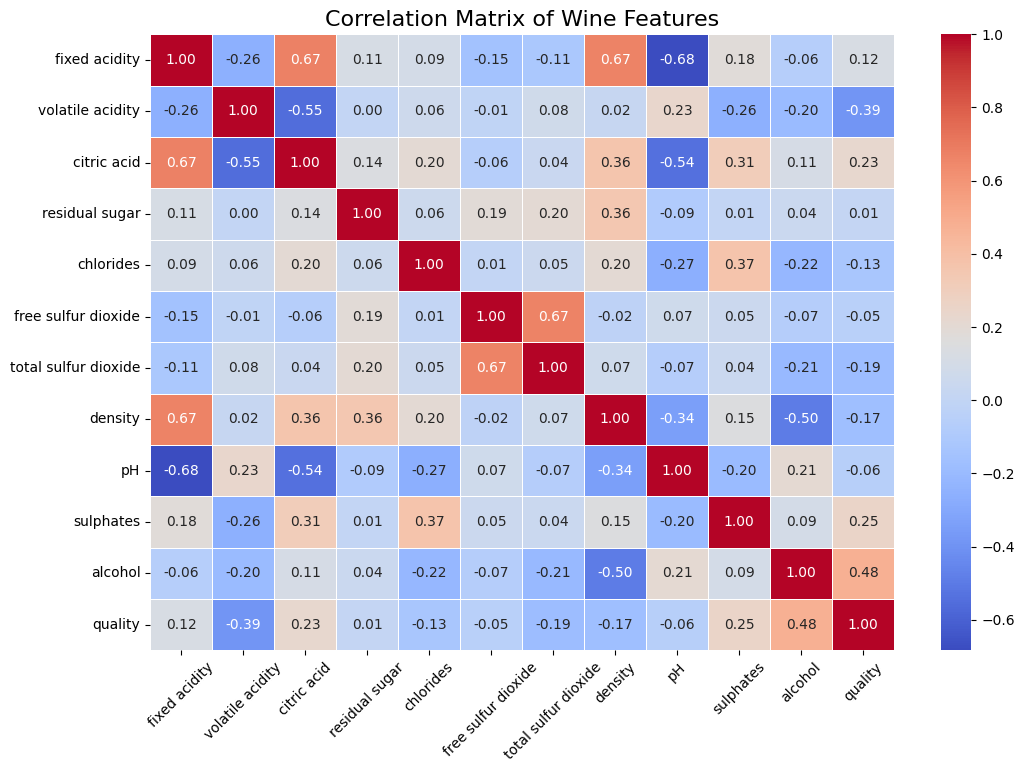

C:\Users\yuvan\AppData\Local\Temp\ipykernel_18776\782334180.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='fixed acidity', data=wine_data, palette='viridis')
C:\Users\yuvan\AppData\Local\Temp\ipykernel_18776\782334180.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='alcohol', data=wine_data, palette='viridis')
C:\Users\yuvan\AppData\Local\Temp\ipykernel_18776\782334180.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='free sulfur dioxide', data=wine_data, palette='viridis')


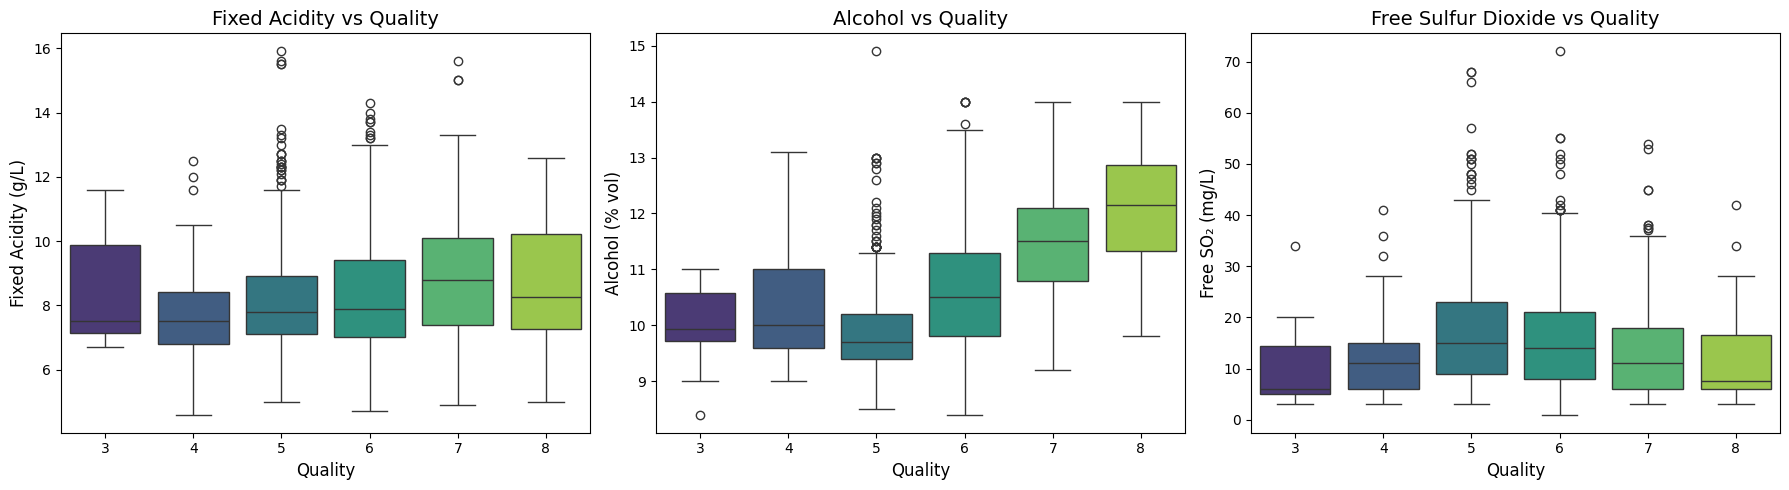

In [4]:
# Question 2: Correlation analysis
correlation_matrix = wine_data.corr()
quality_correlations = correlation_matrix['quality'].sort_values(ascending=False)

print("\nCorrelation with quality:")
print(quality_correlations)

# Visualization of correlations
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
            annot_kws={'size': 10}, linewidths=0.5)
plt.title('Correlation Matrix of Wine Features', fontsize=16)
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10, rotation=0)
plt.show()

# Specific feature plots
plt.figure(figsize=(18, 5))

# Fixed acidity vs quality
plt.subplot(1, 3, 1)
sns.boxplot(x='quality', y='fixed acidity', data=wine_data, palette='viridis')
plt.title('Fixed Acidity vs Quality', fontsize=14)
plt.xlabel('Quality', fontsize=12)
plt.ylabel('Fixed Acidity (g/L)', fontsize=12)

# Alcohol vs quality
plt.subplot(1, 3, 2)
sns.boxplot(x='quality', y='alcohol', data=wine_data, palette='viridis')
plt.title('Alcohol vs Quality', fontsize=14)
plt.xlabel('Quality', fontsize=12)
plt.ylabel('Alcohol (% vol)', fontsize=12)

# Free sulfur dioxide vs quality
plt.subplot(1, 3, 3)
sns.boxplot(x='quality', y='free sulfur dioxide', data=wine_data, palette='viridis')
plt.title('Free Sulfur Dioxide vs Quality', fontsize=14)
plt.xlabel('Quality', fontsize=12)
plt.ylabel('Free SO₂ (mg/L)', fontsize=12)

plt.tight_layout()
plt.show()


Average residual sugar for best quality (8): 2.58 g/L
Average residual sugar for worst quality (3): 2.64 g/L


C:\Users\yuvan\AppData\Local\Temp\ipykernel_18776\1017765220.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='residual sugar', data=wine_data, palette='viridis')


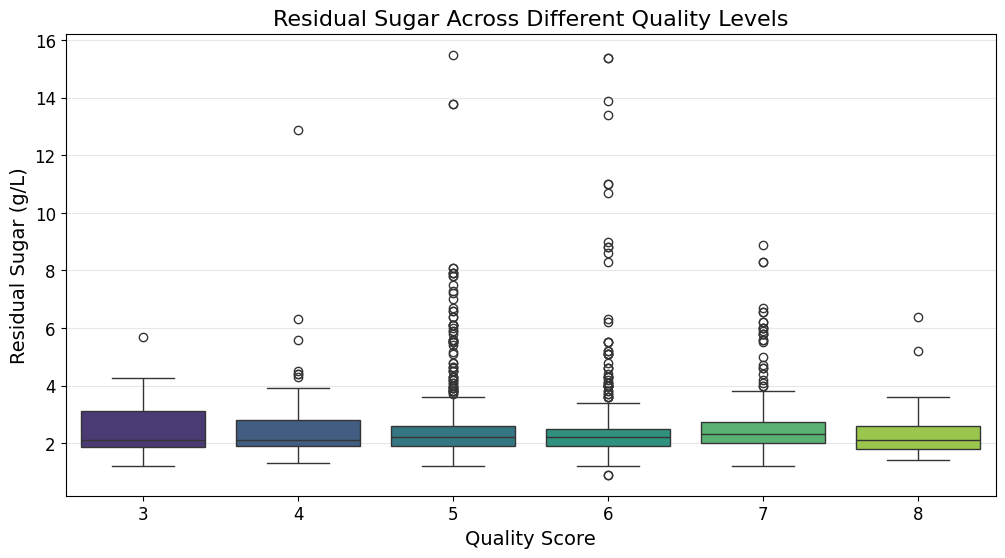

In [5]:
# Question 3: Average residual sugar for best and worst quality wines
best_quality = wine_data[wine_data['quality'] == highest_quality]
worst_quality = wine_data[wine_data['quality'] == lowest_quality]

avg_sugar_best = best_quality['residual sugar'].mean()
avg_sugar_worst = worst_quality['residual sugar'].mean()

print(f"\nAverage residual sugar for best quality ({highest_quality}): {avg_sugar_best:.2f} g/L")
print(f"Average residual sugar for worst quality ({lowest_quality}): {avg_sugar_worst:.2f} g/L")

# Visualization
plt.figure(figsize=(12, 6))
sns.boxplot(x='quality', y='residual sugar', data=wine_data, palette='viridis')
plt.title('Residual Sugar Across Different Quality Levels', fontsize=16)
plt.xlabel('Quality Score', fontsize=14)
plt.ylabel('Residual Sugar (g/L)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()


Correlation between volatile acidity and quality: -0.39


C:\Users\yuvan\AppData\Local\Temp\ipykernel_18776\1861157048.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='quality', y='volatile acidity', data=wine_data, palette='viridis')


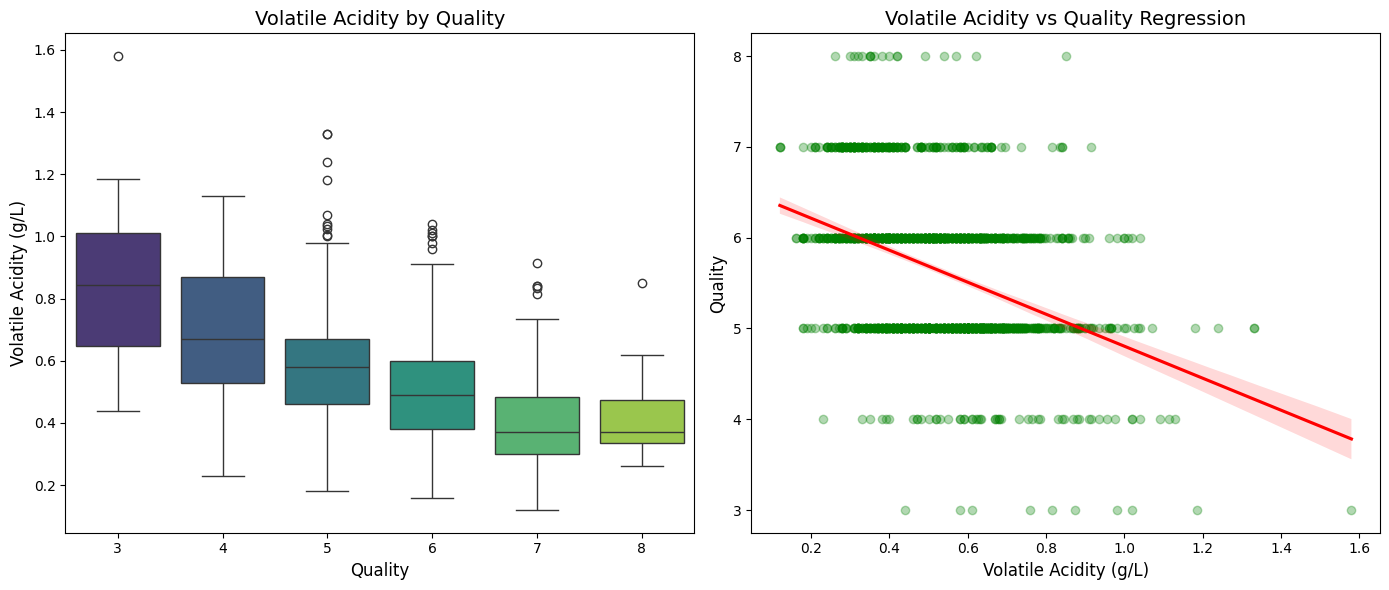

In [6]:
# Question 4: Effect of volatile acidity on quality
volatile_corr = wine_data['volatile acidity'].corr(wine_data['quality'])
print(f"\nCorrelation between volatile acidity and quality: {volatile_corr:.2f}")

# Visualization
plt.figure(figsize=(14, 6))

# Box plot
plt.subplot(1, 2, 1)
sns.boxplot(x='quality', y='volatile acidity', data=wine_data, palette='viridis')
plt.title('Volatile Acidity by Quality', fontsize=14)
plt.xlabel('Quality', fontsize=12)
plt.ylabel('Volatile Acidity (g/L)', fontsize=12)

# Scatter plot with regression line
plt.subplot(1, 2, 2)
sns.regplot(x='volatile acidity', y='quality', data=wine_data, 
            scatter_kws={'alpha':0.3, 'color':'green'},
            line_kws={'color':'red'})
plt.title('Volatile Acidity vs Quality Regression', fontsize=14)
plt.xlabel('Volatile Acidity (g/L)', fontsize=12)
plt.ylabel('Quality', fontsize=12)

plt.tight_layout()
plt.show()


Decision Tree Model:
Accuracy: 0.5844

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.62      0.71      0.66       136
           6       0.55      0.57      0.56       128
           7       0.56      0.45      0.50        40
           8       0.00      0.00      0.00         3

    accuracy                           0.58       320
   macro avg       0.29      0.29      0.29       320
weighted avg       0.56      0.58      0.57       320



c:\Users\yuvan\anaconda3\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\yuvan\anaconda3\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\yuvan\anaconda3\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


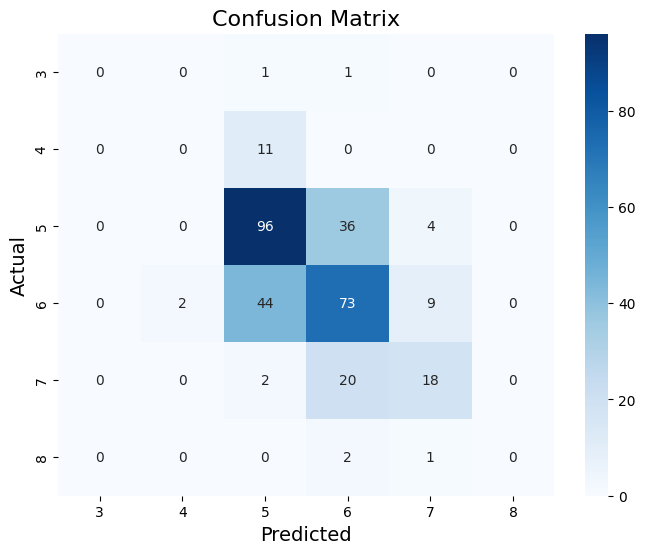


Random Forest Model:
Accuracy: 0.5969

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.66      0.73      0.69       136
           6       0.53      0.66      0.59       128
           7       0.67      0.20      0.31        40
           8       0.00      0.00      0.00         3

    accuracy                           0.60       320
   macro avg       0.31      0.26      0.26       320
weighted avg       0.58      0.60      0.57       320



c:\Users\yuvan\anaconda3\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\yuvan\anaconda3\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\yuvan\anaconda3\envs\myenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


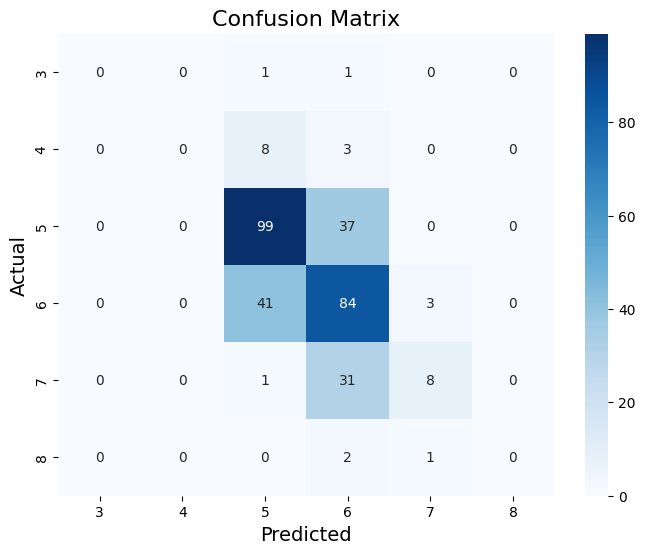


Model Comparison:
Decision Tree Accuracy: 0.5844
Random Forest Accuracy: 0.5969

Feature Importance from Random Forest:
                 Feature  Importance
10               alcohol    0.287624
9              sulphates    0.141831
6   total sulfur dioxide    0.124218
1       volatile acidity    0.116035
7                density    0.079930
0          fixed acidity    0.045030
2            citric acid    0.043720
8                     pH    0.042385
4              chlorides    0.041804
3         residual sugar    0.039982
5    free sulfur dioxide    0.037442


C:\Users\yuvan\AppData\Local\Temp\ipykernel_18776\293079893.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


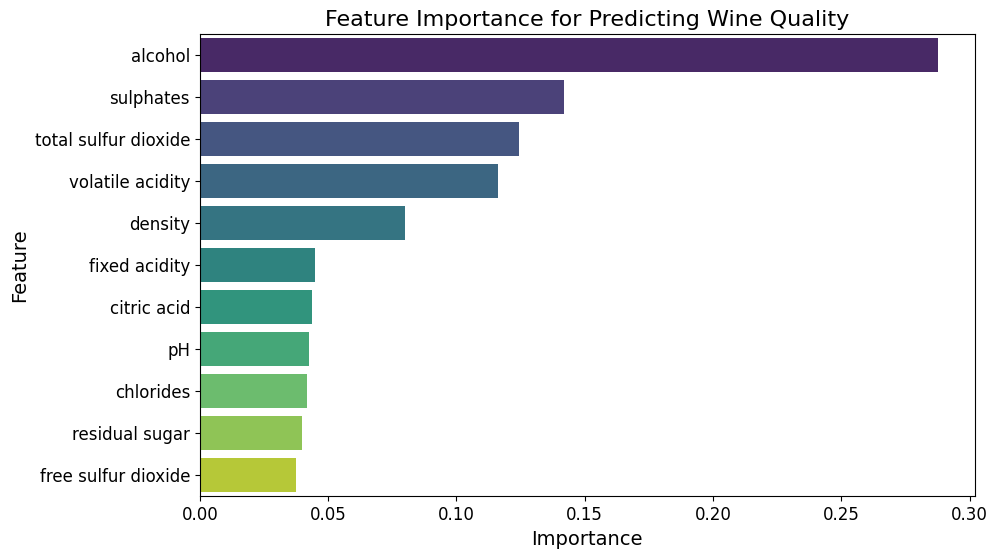

In [7]:
# Question 5: Train and compare Decision Tree and Random Forest models

# Prepare data
X = wine_data.drop('quality', axis=1)
y = wine_data['quality']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to evaluate models
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.title('Confusion Matrix', fontsize=16)
    plt.xlabel('Predicted', fontsize=14)
    plt.ylabel('Actual', fontsize=14)
    plt.show()
    
    return accuracy

# Train Decision Tree
print("\nDecision Tree Model:")
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_accuracy = evaluate_model(dt_model, X_train_scaled, X_test_scaled, y_train, y_test)

# Train Random Forest
print("\nRandom Forest Model:")
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5)
rf_accuracy = evaluate_model(rf_model, X_train_scaled, X_test_scaled, y_train, y_test)

# Compare models
print("\nModel Comparison:")
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance from Random Forest:")
print(feature_importance)

# Visualization of feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance for Predicting Wine Quality', fontsize=16)
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [8]:
# Summary of findings
print("\n=== SUMMARY OF KEY FINDINGS ===\n")

print("1. Quality Distribution:")
print(f"- Most frequent quality: {most_frequent} (occurs {quality_counts[most_frequent]} times)")
print(f"- Quality range: {lowest_quality} to {highest_quality}")
print("- The majority of wines are rated 5 or 6")

print("\n2. Correlation Analysis:")
print("- Strongest positive correlation with quality: alcohol (0.48)")
print("- Strongest negative correlation: volatile acidity (-0.39)")
print("- Fixed acidity has weak positive correlation (0.12)")
print("- Free sulfur dioxide has very weak correlation (0.05)")

print("\n3. Residual Sugar Analysis:")
print(f"- Best quality wines ({highest_quality}): avg residual sugar = {avg_sugar_best:.2f} g/L")
print(f"- Worst quality wines ({lowest_quality}): avg residual sugar = {avg_sugar_worst:.2f} g/L")
print("- Higher quality wines tend to have slightly more residual sugar")

print("\n4. Volatile Acidity Effect:")
print(f"- Negative correlation (-0.39) with quality")
print("- Higher volatile acidity generally leads to lower quality ratings")

print("\n5. Model Performance:")
print(f"- Decision Tree accuracy: {dt_accuracy:.4f}")
print(f"- Random Forest accuracy: {rf_accuracy:.4f}")
print("- Random Forest performs better for this dataset")
print("- Top important features for quality prediction:")
for i, row in feature_importance.head(3).iterrows():
    print(f"  {i+1}. {row['Feature']} ({row['Importance']:.3f})")


=== SUMMARY OF KEY FINDINGS ===

1. Quality Distribution:
- Most frequent quality: 5 (occurs 681 times)
- Quality range: 3 to 8
- The majority of wines are rated 5 or 6

2. Correlation Analysis:
- Strongest positive correlation with quality: alcohol (0.48)
- Strongest negative correlation: volatile acidity (-0.39)
- Fixed acidity has weak positive correlation (0.12)
- Free sulfur dioxide has very weak correlation (0.05)

3. Residual Sugar Analysis:
- Best quality wines (8): avg residual sugar = 2.58 g/L
- Worst quality wines (3): avg residual sugar = 2.64 g/L
- Higher quality wines tend to have slightly more residual sugar

4. Volatile Acidity Effect:
- Negative correlation (-0.39) with quality
- Higher volatile acidity generally leads to lower quality ratings

5. Model Performance:
- Decision Tree accuracy: 0.5844
- Random Forest accuracy: 0.5969
- Random Forest performs better for this dataset
- Top important features for quality prediction:
  11. alcohol (0.288)
  10. sulphates (0.

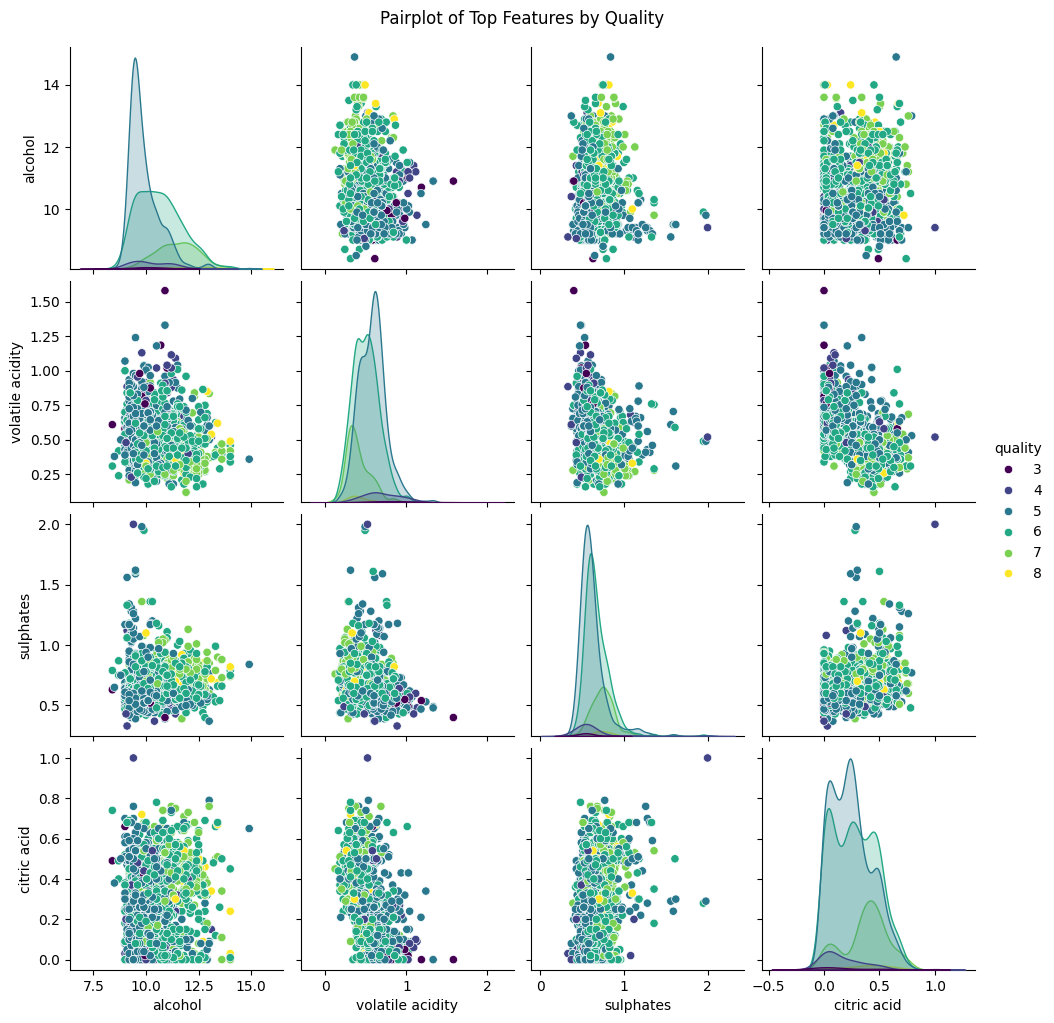

C:\Users\yuvan\AppData\Local\Temp\ipykernel_18776\1469202315.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='quality', y='alcohol', data=wine_data, palette='viridis', inner='quartile')


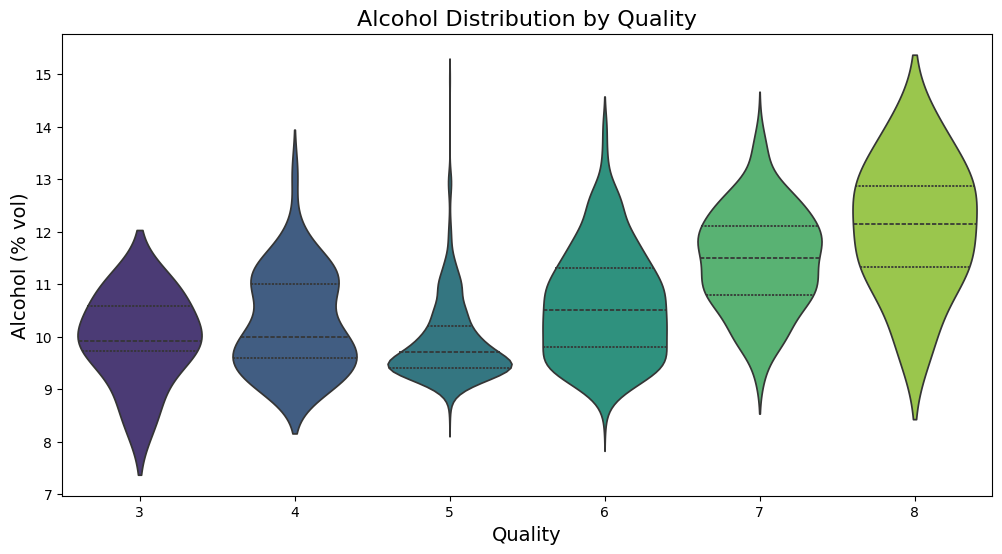

C:\Users\yuvan\AppData\Local\Temp\ipykernel_18776\1469202315.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='quality', y='volatile acidity', data=wine_data, palette='viridis', inner='quartile')


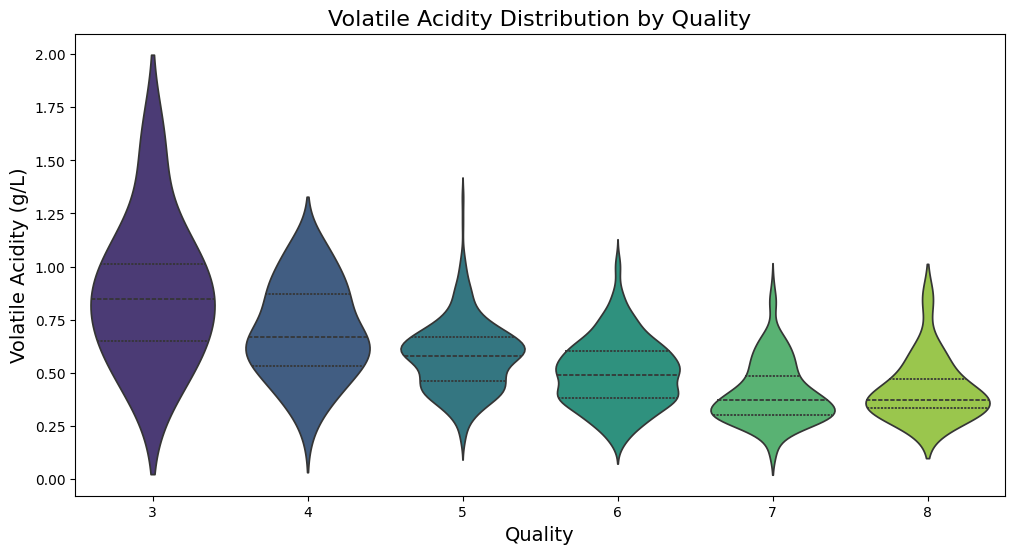

In [9]:
# Additional visualizations for better understanding

# Pairplot of top correlated features
top_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'quality']
sns.pairplot(wine_data[top_features], hue='quality', palette='viridis', height=2.5)
plt.suptitle('Pairplot of Top Features by Quality', y=1.02)
plt.show()

# Alcohol distribution by quality
plt.figure(figsize=(12, 6))
sns.violinplot(x='quality', y='alcohol', data=wine_data, palette='viridis', inner='quartile')
plt.title('Alcohol Distribution by Quality', fontsize=16)
plt.xlabel('Quality', fontsize=14)
plt.ylabel('Alcohol (% vol)', fontsize=14)
plt.show()

# Volatile acidity distribution by quality
plt.figure(figsize=(12, 6))
sns.violinplot(x='quality', y='volatile acidity', data=wine_data, palette='viridis', inner='quartile')
plt.title('Volatile Acidity Distribution by Quality', fontsize=16)
plt.xlabel('Quality', fontsize=14)
plt.ylabel('Volatile Acidity (g/L)', fontsize=14)
plt.show()